In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    ('r9w9h1af', 'SM'): {},
    ('pisuh9ha', r'FM (Heun,OT,$\mathbb{E}[\sum]$)'): {},
    ('wnjf6c57', r'FM (Heun,OT,$\sum\mathbb{E}$)'): {},
}

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('r9w9h1af', 'SM'): {'cfg': Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
                                  out_dir='/root/workspace/out/dafm',
                                  run_subdir='runs',
                                  prediction_filename='trajectories.parquet',
                                  device='cuda',
                                  alt_id='r9w9h1af',
                                  rng_seed=2376999025,
                                  fit=True,
                                  id=56,
                                  dataset=Lorenz96(predicted_state_count=10000,
                                                   time_step_count=100,
                                                   time_step_count_drop_first=0,
                                                   time_step_size=0.01,
                                                   observe_every_n_time_steps=1,
                                                   observe=Exponentiat

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 1
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'^predicted_state_[0-9]+_dim_{dim}$')]].mean(axis=1)

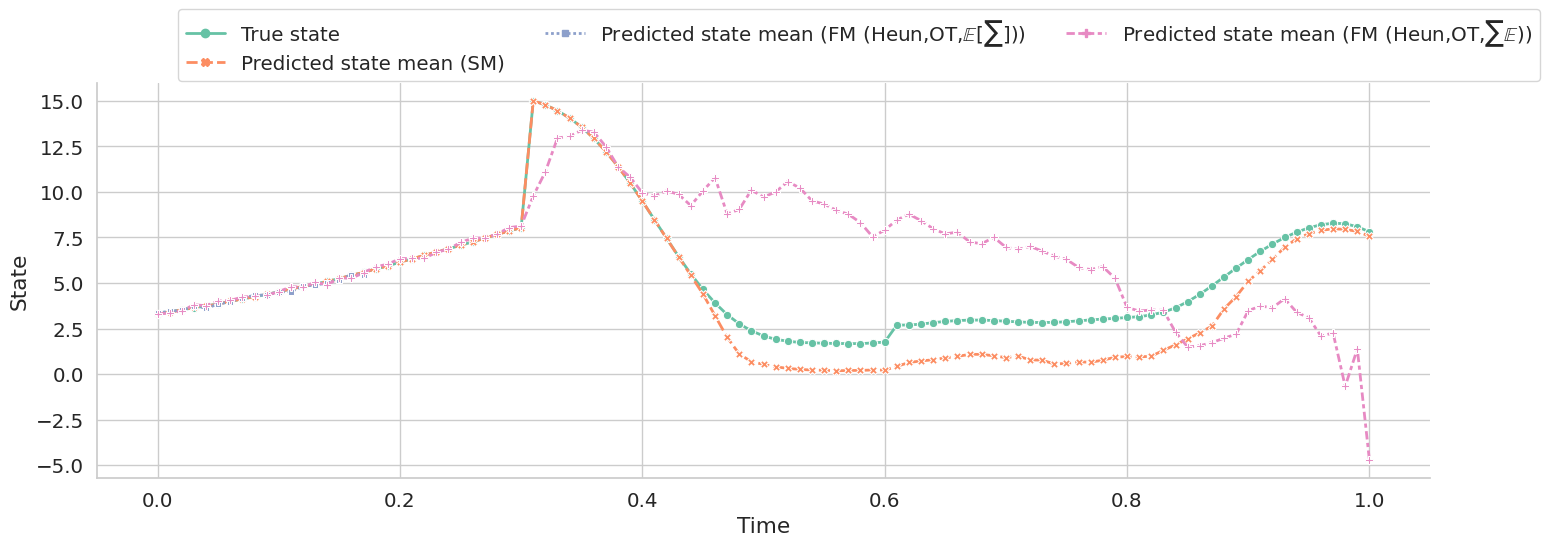

In [7]:
df_line = pd.concat([
    v['trajectories']['times'].rename('Time'),
    v['trajectories'][f'true_state_dim_{dim}'].rename('True state'),
    # v['trajectories'][f'observation_dim_{dim}'].rename('Observation'),
    *(
        v['trajectories'][f'predicted_state_mean_{dim}'].rename(f'Predicted state mean ({k[1]})')
        for k, v in cfgs.items()
    )
], axis=1)
to_plot = df_line
# to_plot = df_line[['Time', *df_line.columns[df_line.columns.str.startswith('Predicted')]]].transform(lambda x: x if x.name == 'Time' else x - df_line['True state']).abs()
to_plot = to_plot.melt(id_vars=['Time'], var_name='Source', value_name='State')
plot = (
    sns.relplot(
        data=to_plot,
        kind='line',
        x='Time',
        y='State',
        hue='Source',
        style='Source',
        markers=True,
        aspect=3,
        linewidth=2,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    # .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(to_plot['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.12),
    frameon=True,
    fancybox=True,
)

In [8]:
df = df_line
print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).pow(2).mean().pow(1/2))
df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).abs().mean()
# (df.T - df['True state']).T.pow(2).sum()

Time                                                      0.578792
True state                                                0.000000
Predicted state mean (SM)                                 1.264406
Predicted state mean (FM (Heun,OT,$\mathbb{E}[\sum]$))    0.072178
Predicted state mean (FM (Heun,OT,$\sum\mathbb{E}$))      4.147433
dtype: float32


Time                                                      0.500000
True state                                                0.000000
Predicted state mean (SM)                                 0.872438
Predicted state mean (FM (Heun,OT,$\mathbb{E}[\sum]$))    0.058717
Predicted state mean (FM (Heun,OT,$\sum\mathbb{E}$))      2.964922
dtype: float32

In [9]:
plots.save_all_subfigures(plot, 'Predictions')

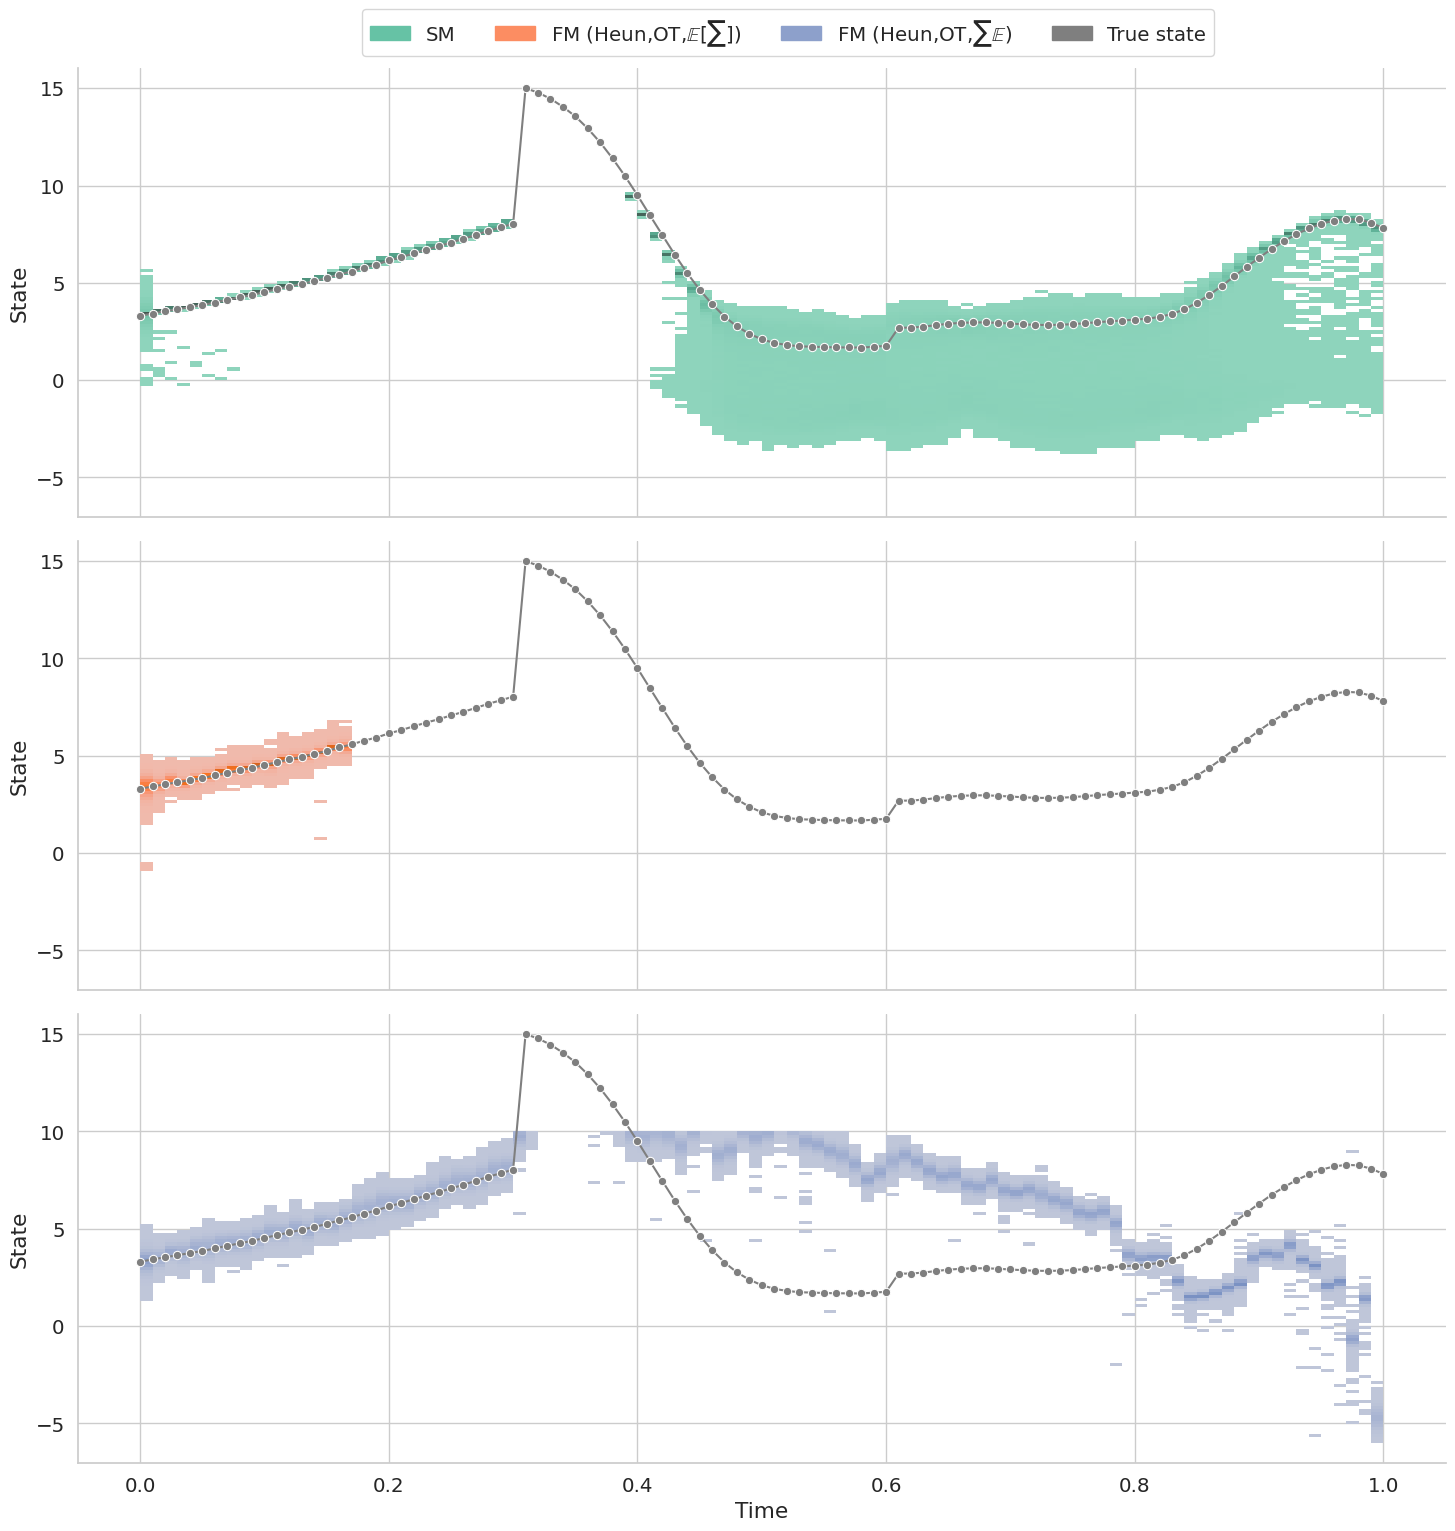

In [10]:
df_hist = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.contains(f'^predicted_state_[0-9]+_dim_{dim}$')])
    .rename(columns={'times': 'Time'})
)
#.melt(id_vars=['Time'], var_name='Source', value_name='State')
line_to_plot = 'True state'
plot = (
    sns.displot(
        data=df_hist,
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        hue_order=[*df_hist['Model'].unique(), line_to_plot],
        palette=[*sns.color_palette()[:len(df_hist['Model'].unique())], 'tab:gray'],
        bins=(v['trajectories']['times'], 101),
        binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
        aspect=3,
        binrange=(None, (-6, 10)),
    )
    .set_titles('')
    # .set(xticks=[])
)
plot.map(
    sns.lineplot,
    data=to_plot.loc[(to_plot['Source'] == line_to_plot), ['Time', 'State', 'Source']],
    x='Time',
    y='State',
    color='tab:gray',
    style='Source',
    markers=True,
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(df_hist['Model'].unique()) + 1,
    title='',
    bbox_to_anchor=(.455, 1.03),
    frameon=True,
    fancybox=True,
)

In [11]:
plots.save_all_subfigures(plot, 'PredictedStateHistogram')